In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl
from clmm import Cosmology

# ============================================================
# CLCosmoSim imports
# ============================================================

CLCOSMO_DIR = "/sps/lsst/users/ebarroso/CLCosmo_Sim"

sys.path.insert(0, f"{CLCOSMO_DIR}")
sys.path.insert(0, f"{CLCOSMO_DIR}/cluster_scaling_relation_DC2")
sys.path.insert(0, f"{CLCOSMO_DIR}/lensing_profile_measurement")
sys.path.insert(0, f"{CLCOSMO_DIR}/modeling")

import _redshift_richness_bins as analysis
import _config_lensing_profiles

import CL_COUNT_modeling_completeness as comp
import CL_COUNT_modeling_purity as pur
import CL_COUNT_modeling_halo_mass_function as hmf
import CL_COUNT_modeling_richness_mass_relation as rm_relation
import CL_COUNT_cluster_abundance as cl_count
import CL_LENSING_cluster_lensing as cl_lensing

# ============================================================
# CROW imports
# ============================================================

from crow import ClusterAbundance, ClusterShearProfile
from crow.recipes.binned_grid import GridBinnedClusterRecipe
from crow.recipes.binned_exact import ExactBinnedClusterRecipe

from crow import completeness_models, mass_proxy, purity_models, kernel

In [2]:
# ============================================================
# Common setup
# ============================================================

# Use same bins as CLCosmoSim
Z_bin = analysis.Z_bin
Richness_bin = analysis.Obs_bin
Z_bin = np.array([zb for zb in analysis.Z_bin if zb[1] <= 0.8])

bins = {
    "redshift_bins": Z_bin,
    "richness_bins": Richness_bin,
}

log_rich_bins = np.log10(Richness_bin)

# Cosmology
Omega_m_true = 0.2648
Omega_b_true = 0.0448
Omega_c_true = Omega_m_true - Omega_b_true
sigma8_true = 0.8
H0_true = 71.0
ns_true = 0.963

cosmo_clmm = Cosmology(
    H0=H0_true,
    Omega_dm0=Omega_c_true,
    Omega_b0=Omega_b_true,
    Omega_k0=0.0,
)

cosmo = ccl.Cosmology(
    Omega_c=Omega_c_true,
    Omega_b=Omega_b_true,
    h=H0_true / 100.0,
    sigma8=sigma8_true,
    n_s=ns_true,
)

# HMF
massdef = ccl.halos.massdef.MassDef(200, "critical")
hmd = ccl.halos.hmfunc.MassFuncDespali16(mass_def=massdef)

# Survey area
Sredmapper = 439.78987  # deg2
Omega = Sredmapper * (np.pi / 180.0) ** 2
sky_area = Sredmapper

# Selection parameters
theta_purity = [
    np.log(10) * 0.8612,
    np.log(10) * 0.3527,
    2.2183,
    -0.6592,
]

theta_completeness = [
    1.1321,
    0.7751,
    13.31,
    0.2025,
]

# MOR parameters
log10m0, z0 = np.log10(10**14.3), 0.5

proxy_mu0 = 3.345953364933381
proxy_muz = 0.06378674560099672
proxy_mulog10m = 2.2274595352385975

proxy_sigma0 = 0.5634900828247924
proxy_sigmaz = -0.04529427946062734
proxy_sigmalog10m = 0.09764409931399064

theta_rm = [
    log10m0,
    z0,
    proxy_mu0,
    proxy_muz,
    proxy_mulog10m,
    proxy_sigma0,
    proxy_sigmaz,
    proxy_sigmalog10m,
]

# Grids
richness_grid = np.logspace(np.log10(20), np.log10(200), 300)
logm_grid = np.linspace(12, 15.5, 300)
z_grid = np.linspace(0.2, 1.0, 300)

grids = {
    "logm_grid": logm_grid,
    "z_grid": z_grid,
    "richness_grid": richness_grid,
}

mass_interval = (logm_grid[0], logm_grid[-1])
mass_grid_size = len(logm_grid)
redshift_grid_size = int(len(z_grid) / len(Z_bin))
proxy_grid_size = int(len(richness_grid) / len(log_rich_bins))
# Radius setup
# radius_min = 1.0
# radius_max = 3.5

# r_edges = _config_lensing_profiles.bin_edges
# r_centers = np.array([
#     (2.0 / 3.0) * (r_edges[i + 1]**3 - r_edges[i]**3) / (r_edges[i + 1]**2 - r_edges[i]**2)
#     for i in range(len(r_edges) - 1)
# ])

# mask_r = (r_centers > radius_min) & (r_centers < radius_max)
# r_reshaped = r_centers[mask_r]
# idx_r = np.where(mask_r)[0]
# radius_bins = np.array([[r_edges[i], r_edges[i + 1]] for i in idx_r])
r_reshaped = np.array([2.0])
print("Z bins:", Z_bin)
print("Richness bins:", Richness_bin)
print("Radii:", r_reshaped)

Z bins: [[0.2 0.3]
 [0.3 0.4]
 [0.4 0.5]
 [0.5 0.6]
 [0.6 0.7]
 [0.7 0.8]]
Richness bins: [[ 20  35]
 [ 35  70]
 [ 70 100]
 [100 200]]
Radii: [2.]


In [3]:
# ============================================================
# CLCosmoSim prediction
# ============================================================

count_modelling = {
    "dNdzdlogMdOmega": None,
    "richness_mass_relation": None,
    "completeness": None,
    "purity": None,
}

params = {
    "params_purity": theta_purity,
    "params_completeness": theta_completeness,
    "params_richness_mass_relation": theta_rm,
    "CCL_cosmology": cosmo,
    "halo_mass_distribution": hmd,
    "params_concentration_mass_relation": None,
}

compute = {
    "compute_dNdzdlogMdOmega": True,
    "compute_richness_mass_relation": True,
    "compute_completeness": True,
    "compute_dNdzdlogMdOmega_log_slope": False,
    "compute_purity": True,
    "compute_halo_bias": False,
}

adds_N = {
    "add_purity": True,
    "add_completeness": True,
}

adds_NDS = {
    "add_purity": False,
    "add_completeness": True,
}

count_modelling = cl_count.recompute_count_modelling(
    count_modelling,
    grids=grids,
    compute=compute,
    params=params,
)

integrand_count = cl_count.define_count_integrand(count_modelling, adds_N)
integrand_count_ds = cl_count.define_count_integrand(count_modelling, adds_NDS)

N_clcosmo = Omega * cl_count.Cluster_SurfaceDensity_ProxyZ(
    bins,
    integrand_count=integrand_count,
    grids=grids,
)

cluster_lensing_clcosmo = cl_lensing.compute_cluster_lensing(
    r_reshaped,
    None,
    logm_grid,
    z_grid,
    cosmo,
    cosmo_clmm,
    two_halo=False,
)

NDS_clcosmo = Omega * cl_lensing.Cluster_dNd0mega_Lensing_ProxyZ(
    bins,
    integrand_count=integrand_count_ds,
    cluster_lensing=cluster_lensing_clcosmo,
    lensing_radius=r_reshaped,
    grids=grids,
)

DS_clcosmo = NDS_clcosmo / N_clcosmo

# Convert from CLCosmoSim convention [r, richness, z] to [z, richness, r]
DS_clcosmo_zlr = np.transpose(DS_clcosmo, (2, 1, 0))
N_clcosmo_zl = N_clcosmo.T
print("N_clcosmo shape:", N_clcosmo.shape)
print("NDS_clcosmo shape:", NDS_clcosmo.shape)
print("DS_clcosmo_zlr shape:", DS_clcosmo_zlr.shape)

N_clcosmo shape: (4, 6)
NDS_clcosmo shape: (1, 4, 6)
DS_clcosmo_zlr shape: (6, 4, 1)


In [4]:
# ============================================================
# CROW prediction
# ============================================================

cluster_abundance = ClusterAbundance(cosmo, hmd)

mass_richness_unb = mass_proxy.MurataUnbinned(
    pivot_log_mass=14.3,
    pivot_redshift=0.5,
)

mass_richness_unb.parameters["mu0"] = proxy_mu0
mass_richness_unb.parameters["mu1"] = proxy_mulog10m / np.log(10.0)
mass_richness_unb.parameters["mu2"] = proxy_muz

mass_richness_unb.parameters["sigma0"] = proxy_sigma0
mass_richness_unb.parameters["sigma1"] = proxy_sigmalog10m / np.log(10.0)
mass_richness_unb.parameters["sigma2"] = proxy_sigmaz

mass_richness_bin = mass_proxy.MurataBinned(
    pivot_log_mass=14.3,
    pivot_redshift=0.5,
)

mass_richness_bin.parameters["mu0"] = proxy_mu0
mass_richness_bin.parameters["mu1"] = proxy_mulog10m / np.log(10.0)
mass_richness_bin.parameters["mu2"] = proxy_muz

mass_richness_bin.parameters["sigma0"] = proxy_sigma0
mass_richness_bin.parameters["sigma1"] = proxy_sigmalog10m / np.log(10.0)
mass_richness_bin.parameters["sigma2"] = proxy_sigmaz



purity_aguena = purity_models.PurityAguena16LnProxy()
completeness_aguena = completeness_models.CompletenessAguena16()
redshift_distribution = kernel.SpectroscopicRedshift()

cl_shear_crow = ClusterShearProfile(
    cosmo,
    hmd,
    is_delta_sigma=True,
    cluster_concentration=3.8,
)
cl_abundance = ClusterAbundance(
    cosmo,
    hmd
)


recipe_crow_grid = GridBinnedClusterRecipe(
    cluster_theory=cl_shear_crow,
    mass_distribution=mass_richness_unb,
    redshift_distribution=redshift_distribution,
    mass_interval=mass_interval,
    mass_grid_size=mass_grid_size,
    redshift_grid_size=redshift_grid_size,
    proxy_grid_size=proxy_grid_size,
    purity=purity_aguena,
    completeness=completeness_aguena,
)

recipe_crow_grid2 = GridBinnedClusterRecipe(
    cluster_theory=cl_abundance,
    mass_distribution=mass_richness_unb,
    redshift_distribution=redshift_distribution,
    mass_interval=mass_interval,
    mass_grid_size=mass_grid_size,
    redshift_grid_size=redshift_grid_size,
    proxy_grid_size=proxy_grid_size,
    purity=purity_aguena,
    completeness=completeness_aguena,
)

recipe_shear_crow_exact = ExactBinnedClusterRecipe(
    cluster_theory=cl_shear_crow,
    mass_distribution=mass_richness_bin,
    redshift_distribution=redshift_distribution,
    mass_interval=mass_interval,
    purity=purity_aguena,
    completeness=completeness_aguena,
)


recipe_crow_grid.setup()
recipe_crow_grid2.setup()


In [5]:
# Evaluate CROW counts and lensing numerator
from crow import ClusterProperty
property1 = ClusterProperty.DELTASIGMA
N_crow = np.zeros((len(Z_bin), len(log_rich_bins)))
N_crow2 = np.zeros((len(Z_bin), len(log_rich_bins)))

N_crow_exact = np.zeros((len(Z_bin), len(log_rich_bins)))
NDS_crow = np.zeros((len(Z_bin), len(log_rich_bins), len(r_reshaped)))
NDS_crow_exact = np.zeros((len(Z_bin), len(log_rich_bins), len(r_reshaped)))

print(Z_bin)

print(NDS_crow.shape)
for i, zb in enumerate(Z_bin):
    for j, rbich in enumerate(log_rich_bins):
        N_crow[i, j] = recipe_crow_grid.evaluate_theory_prediction_counts(
            np.array(zb),
            np.array(rbich),
            sky_area,
        )
        NDS_crow[i, j, :] = recipe_crow_grid.evaluate_theory_prediction_lensing_profile(
                np.array(zb),
                np.array(rbich),
                np.array(r_reshaped),
                sky_area,
                property1
            )
        # N_crow2[i, j] = recipe_crow_grid.evaluate_theory_prediction_counts(
        #     np.array(zb),
        #     np.array(rbich),
        #     sky_area,
        # )
        N_crow_exact[i, j] = recipe_shear_crow_exact.evaluate_theory_prediction_counts(
            np.array(zb),
            np.array(rbich),
            sky_area,
        )
        NDS_crow_exact[i, j, :] = recipe_shear_crow_exact.evaluate_theory_prediction_lensing_profile(
                np.array(zb),
                np.array(rbich),
                np.array(r_reshaped),
                sky_area,
                property1
            )
        print(f"bin {i} {j}")
DS_crow = NDS_crow / N_crow[:, :, None]
DS_crow_exact = NDS_crow_exact / N_crow_exact[:, :, None]
print("N_crow shape:", N_crow.shape)
print("NDS_crow shape:", NDS_crow.shape)
print("DS_crow shape:", DS_crow.shape)

[[0.2 0.3]
 [0.3 0.4]
 [0.4 0.5]
 [0.5 0.6]
 [0.6 0.7]
 [0.7 0.8]]
(6, 4, 1)
bin 0 0
bin 0 1
bin 0 2
bin 0 3
bin 1 0
bin 1 1
bin 1 2
bin 1 3
bin 2 0
bin 2 1
bin 2 2
bin 2 3
bin 3 0
bin 3 1
bin 3 2
bin 3 3
bin 4 0
bin 4 1
bin 4 2
bin 4 3
bin 5 0
bin 5 1
bin 5 2
bin 5 3
N_crow shape: (6, 4)
NDS_crow shape: (6, 4, 1)
DS_crow shape: (6, 4, 1)


Using radius index 0: R = 2.0000 Mpc


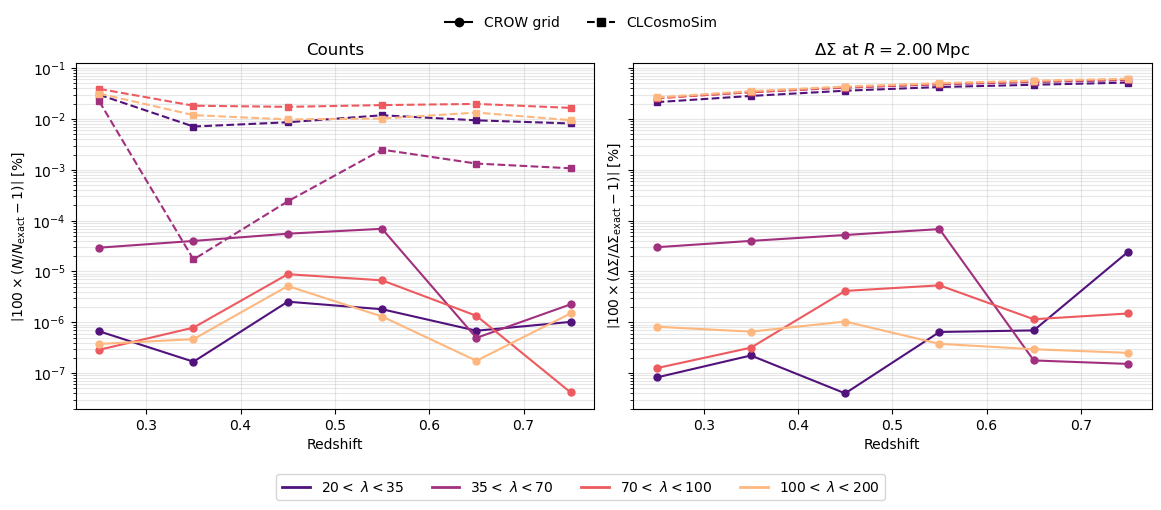

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# Configuration
# ============================================================

target_radius = 2.0  # Mpc

N_clcosmo = N_clcosmo_zl  # counts from CLCosmoSim

z_edges = np.asarray(Z_bin)
z_centers = 0.5 * (z_edges[:, 0] + z_edges[:, 1])


# ============================================================
# Helpers
# ============================================================

def absolute_percent_residual(model, exact):
    """
    Return |100 * (model / exact - 1)|.
    """
    model = np.asarray(model, dtype=float)
    exact = np.asarray(exact, dtype=float)

    out = np.full_like(model, np.nan, dtype=float)
    mask = np.isfinite(model) & np.isfinite(exact) & (exact != 0.0)
    out[mask] = np.abs(100.0 * (model[mask] / exact[mask] - 1.0))
    return out


def z_bin_label(b):
    b = np.asarray(b, dtype=float).reshape(-1)
    if b.size == 2:
        return rf"${b[0]:.2f}<z<{b[1]:.2f}$"
    return str(b)


def positive_for_log(y):
    """
    Mask zero/negative values for log-scale plotting.
    """
    y = np.asarray(y, dtype=float)
    return np.where(y > 0.0, y, np.nan)


# ============================================================
# Residuals relative to CROW exact
# ============================================================

res_N_crow = absolute_percent_residual(N_crow, N_crow_exact)
res_N_clcosmo = absolute_percent_residual(N_clcosmo, N_crow_exact)

res_DS_crow = absolute_percent_residual(DS_crow, DS_crow_exact)
res_DS_clcosmo = absolute_percent_residual(DS_clcosmo_zlr, DS_crow_exact)


# ============================================================
# Select fixed radius for DeltaSigma
# ============================================================

r = np.asarray(r_reshaped, dtype=float).reshape(-1)
r_index = np.argmin(np.abs(r - target_radius))
r_selected = r[r_index]

print(f"Using radius index {r_index}: R = {r_selected:.4f} Mpc")


# ============================================================
# Axis setup
# ============================================================

n_z, n_rich = res_N_crow.shape
rich_colors = plt.cm.magma(np.linspace(0.25, 0.85, n_rich))
rich_edges = 10**(log_rich_bins)

# Plot at the middle of each bin in normal richness lambda
rich_centers = 0.5 * (rich_edges[:, 0] + rich_edges[:, 1])

# Tick labels: only the bin center, not the bin range
rich_labels = [rf"${c:.0f}$" for c in rich_centers]

x_rich = rich_centers
z_labels = [z_bin_label(b) for b in Z_bin]


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.2),
    constrained_layout=True,
    sharey=True,
)

# Use same default color per redshift bin in both panels
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]


# ------------------------------------------------------------
# Panel 1: Counts residuals
# ------------------------------------------------------------

ax = axes[0]

for ir in range(n_rich):
    color = rich_colors[ir]

    ax.plot(
        z_centers,
        positive_for_log(res_N_crow[:, ir]),
        marker="o",
        linestyle="-",
        linewidth=1.5,
        markersize=5,
        color=color,
    )

    ax.plot(
        z_centers,
        positive_for_log(res_N_clcosmo[:, ir]),
        marker="s",
        linestyle="--",
        linewidth=1.5,
        markersize=5,
        color=color,
    )

ax.set_yscale("log")
ax.set_xlabel("Redshift")

ax.set_yscale("log")



ax.set_ylabel(r"$\left|100 \times (N/N_{\rm exact} - 1)\right|$ [%]")
ax.set_title("Counts")
ax.grid(alpha=0.3, which="both")


# ------------------------------------------------------------
# Panel 2: DeltaSigma residuals at fixed radius
# ------------------------------------------------------------

ax = axes[1]

for ir in range(n_rich):
    color = rich_colors[ir]

    ax.plot(
        z_centers,
        positive_for_log(res_DS_crow[:, ir, r_index]),
        marker="o",
        linestyle="-",
        linewidth=1.5,
        markersize=5,
        color=color,
    )

    ax.plot(
        z_centers,
        positive_for_log(res_DS_clcosmo[:, ir, r_index]),
        marker="s",
        linestyle="--",
        linewidth=1.5,
        markersize=5,
        color=color,
    )

ax.set_yscale("log")
ax.set_xlabel("Redshift")


ax.set_ylabel(
    r"$\left|100 \times (\Delta\Sigma/\Delta\Sigma_{\rm exact} - 1)\right|$ [%]"
)
ax.set_title(rf"$\Delta\Sigma$ at $R={r_selected:.2f}\,\mathrm{{Mpc}}$")
ax.grid(alpha=0.3, which="both")


# ============================================================
# Shared legends
# ============================================================

model_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        marker="o",
        linestyle="-",
        linewidth=1.5,
        label="CROW grid",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        marker="s",
        linestyle="--",
        linewidth=1.5,
        label="CLCosmoSim",
    ),
]

rich_handles = [
    Line2D(
        [0],
        [0],
        color=rich_colors[i],
        linestyle="-",
        linewidth=2,
        label=rf"${rich_edges[i,0]:.0f}<$ $\lambda<{rich_edges[i,1]:.0f}$",
    )
    for i in range(n_rich)
]

fig.legend(
    handles=model_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2,
    frameon=False,
)

fig.legend(
    handles=rich_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=n_rich,
    frameon=True,
)

# fig.savefig(
#     f"./figures/precision_comparison_by_redshift_R{r_selected:.2f}Mpc.pdf",
#     bbox_inches="tight",
#     pad_inches=0.03,
# )

plt.show()

Using radius index 0: R = 2.0000 Mpc


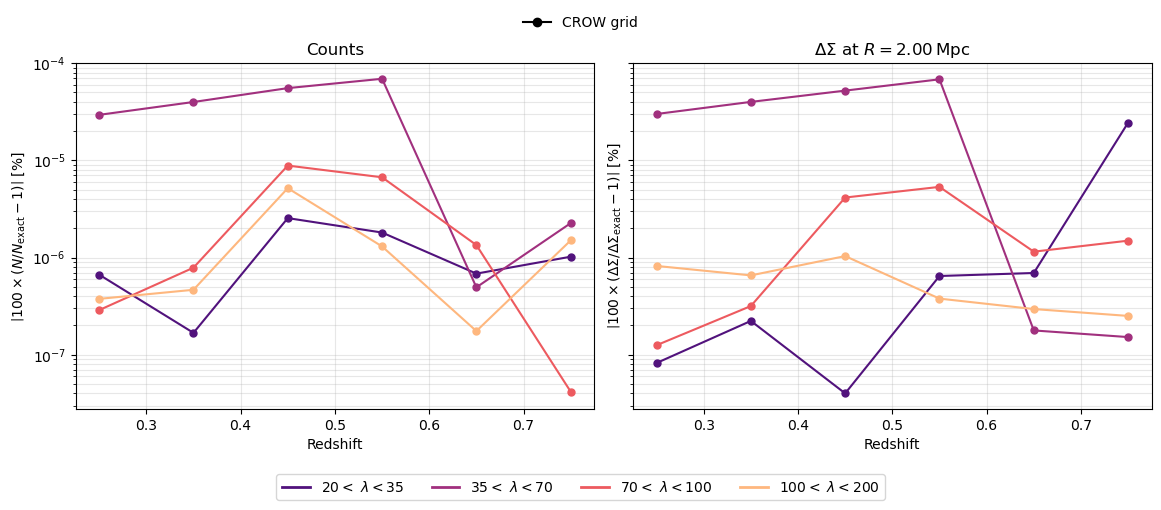

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# Configuration
# ============================================================

target_radius = 2.0  # Mpc

N_clcosmo = N_clcosmo_zl  # counts from CLCosmoSim

z_edges = np.asarray(Z_bin)
z_centers = 0.5 * (z_edges[:, 0] + z_edges[:, 1])


# ============================================================
# Helpers
# ============================================================

def absolute_percent_residual(model, exact):
    """
    Return |100 * (model / exact - 1)|.
    """
    model = np.asarray(model, dtype=float)
    exact = np.asarray(exact, dtype=float)

    out = np.full_like(model, np.nan, dtype=float)
    mask = np.isfinite(model) & np.isfinite(exact) & (exact != 0.0)
    out[mask] = np.abs(100.0 * (model[mask] / exact[mask] - 1.0))
    return out


def z_bin_label(b):
    b = np.asarray(b, dtype=float).reshape(-1)
    if b.size == 2:
        return rf"${b[0]:.2f}<z<{b[1]:.2f}$"
    return str(b)


def positive_for_log(y):
    """
    Mask zero/negative values for log-scale plotting.
    """
    y = np.asarray(y, dtype=float)
    return np.where(y > 0.0, y, np.nan)


# ============================================================
# Residuals relative to CROW exact
# ============================================================

res_N_crow = absolute_percent_residual(N_crow, N_crow_exact)
res_N_clcosmo = absolute_percent_residual(N_clcosmo, N_crow_exact)

res_DS_crow = absolute_percent_residual(DS_crow, DS_crow_exact)
res_DS_clcosmo = absolute_percent_residual(DS_clcosmo_zlr, DS_crow_exact)


# ============================================================
# Select fixed radius for DeltaSigma
# ============================================================

r = np.asarray(r_reshaped, dtype=float).reshape(-1)
r_index = np.argmin(np.abs(r - target_radius))
r_selected = r[r_index]

print(f"Using radius index {r_index}: R = {r_selected:.4f} Mpc")


# ============================================================
# Axis setup
# ============================================================

n_z, n_rich = res_N_crow.shape
rich_colors = plt.cm.magma(np.linspace(0.25, 0.85, n_rich))
rich_edges = 10**(log_rich_bins)

# Plot at the middle of each bin in normal richness lambda
rich_centers = 0.5 * (rich_edges[:, 0] + rich_edges[:, 1])

# Tick labels: only the bin center, not the bin range
rich_labels = [rf"${c:.0f}$" for c in rich_centers]

x_rich = rich_centers
z_labels = [z_bin_label(b) for b in Z_bin]


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.2),
    constrained_layout=True,
    sharey=True,
)

# Use same default color per redshift bin in both panels
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]


# ------------------------------------------------------------
# Panel 1: Counts residuals
# ------------------------------------------------------------

ax = axes[0]

for ir in range(n_rich):
    color = rich_colors[ir]

    ax.plot(
        z_centers,
        positive_for_log(res_N_crow[:, ir]),
        marker="o",
        linestyle="-",
        linewidth=1.5,
        markersize=5,
        color=color,
    )


ax.set_yscale("log")
ax.set_xlabel("Redshift")

ax.set_yscale("log")



ax.set_ylabel(r"$\left|100 \times (N/N_{\rm exact} - 1)\right|$ [%]")
ax.set_title("Counts")
ax.grid(alpha=0.3, which="both")


# ------------------------------------------------------------
# Panel 2: DeltaSigma residuals at fixed radius
# ------------------------------------------------------------

ax = axes[1]

for ir in range(n_rich):
    color = rich_colors[ir]

    ax.plot(
        z_centers,
        positive_for_log(res_DS_crow[:, ir, r_index]),
        marker="o",
        linestyle="-",
        linewidth=1.5,
        markersize=5,
        color=color,
    )

ax.set_yscale("log")
ax.set_xlabel("Redshift")


ax.set_ylabel(
    r"$\left|100 \times (\Delta\Sigma/\Delta\Sigma_{\rm exact} - 1)\right|$ [%]"
)
ax.set_title(rf"$\Delta\Sigma$ at $R={r_selected:.2f}\,\mathrm{{Mpc}}$")
ax.grid(alpha=0.3, which="both")


# ============================================================
# Shared legends
# ============================================================

model_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        marker="o",
        linestyle="-",
        linewidth=1.5,
        label="CROW grid",
    )
]

rich_handles = [
    Line2D(
        [0],
        [0],
        color=rich_colors[i],
        linestyle="-",
        linewidth=2,
        label=rf"${rich_edges[i,0]:.0f}<$ $\lambda<{rich_edges[i,1]:.0f}$",
    )
    for i in range(n_rich)
]

fig.legend(
    handles=model_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2,
    frameon=False,
)

fig.legend(
    handles=rich_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=n_rich,
    frameon=True,
)

fig.savefig(
    f"./figures/precision_comparison_by_redshift_R{r_selected:.2f}Mpc.pdf",
    bbox_inches="tight",
    pad_inches=0.03,
)

plt.show()